# Trabalho de séries temporais - Pipeline completa para uma serie temporal não estacionária

In [65]:
import warnings
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import STL
import kagglehub
import os
import pandas as pd
import numpy as np
from itertools import product
from matplotlib import pyplot as plt
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)
warnings.filterwarnings("ignore")



## Carregando a base

In [66]:
path_brazil = kagglehub.dataset_download("azminetoushikwasi/brazil-all-international-matches-19142023")

print("Path to dataset files:", path_brazil)

Path to dataset files: C:\Users\migue\.cache\kagglehub\datasets\azminetoushikwasi\brazil-all-international-matches-19142023\versions\4


In [67]:
df_brazil = pd.read_csv(os.path.join(path_brazil, "brazil.csv"))

In [68]:
df_brazil

,Date,Match,Result,Score,Competition
0,20 Sep 1914,Argentina v Brazil,L,3-0,International Friendly
1,27 Sep 1914,Argentina v Brazil,W,0-1,Copa Julio Roca
2,08 Jul 1916,Chile v Brazil,D,1-1,Copa America
3,10 Jul 1916,Argentina v Brazil,D,1-1,Copa America
4,12 Jul 1916,Uruguay v Brazil,L,2-1,Copa America
...,...,...,...,...,...
1029,24 Nov 2022,Brazil v Serbia,W,2-0,FIFA World Cup
1030,28 Nov 2022,Brazil v Switzerland,W,1-0,FIFA World Cup
1031,02 Dec 2022,Cameroon v Brazil,L,1-0,FIFA World Cup
1032,05 Dec 2022,Brazil v Korea Republic,W,4-1,FIFA World Cup


## Fazendo limpeza da base

In [69]:
df_brazil = df_brazil.dropna(subset=['Date', 'Result'])
df_brazil

,Date,Match,Result,Score,Competition
0,20 Sep 1914,Argentina v Brazil,L,3-0,International Friendly
1,27 Sep 1914,Argentina v Brazil,W,0-1,Copa Julio Roca
2,08 Jul 1916,Chile v Brazil,D,1-1,Copa America
3,10 Jul 1916,Argentina v Brazil,D,1-1,Copa America
4,12 Jul 1916,Uruguay v Brazil,L,2-1,Copa America
...,...,...,...,...,...
1029,24 Nov 2022,Brazil v Serbia,W,2-0,FIFA World Cup
1030,28 Nov 2022,Brazil v Switzerland,W,1-0,FIFA World Cup
1031,02 Dec 2022,Cameroon v Brazil,L,1-0,FIFA World Cup
1032,05 Dec 2022,Brazil v Korea Republic,W,4-1,FIFA World Cup


#### Colunas específicas

In [70]:
df_brazil = df_brazil[['Date', 'Result']]
df_brazil

,Date,Result
0,20 Sep 1914,L
1,27 Sep 1914,W
2,08 Jul 1916,D
3,10 Jul 1916,D
4,12 Jul 1916,L
...,...,...
1029,24 Nov 2022,W
1030,28 Nov 2022,W
1031,02 Dec 2022,L
1032,05 Dec 2022,W


#### Transformando coluna de data em formato amigável

In [71]:
df_brazil['Date'] = pd.to_datetime(df_brazil['Date'], format='%d %b %Y')
df_brazil

,Date,Result
0,1914-09-20,L
1,1914-09-27,W
2,1916-07-08,D
3,1916-07-10,D
4,1916-07-12,L
...,...,...
1029,2022-11-24,W
1030,2022-11-28,W
1031,2022-12-02,L
1032,2022-12-05,W


#### Criando regra de negócio da serie temporal

In [72]:
df_brazil['win'] = (df_brazil['Result'] == 'W').astype(int)

df_brazil['year'] = df_brazil['Date'].dt.year

sr_brazil = df_brazil.groupby('year')['win'].sum()
sr_brazil

year
1914     1
1916     2
1917     1
1919     3
1920     1
        ..
2018    13
2019     9
2020     4
2021    12
2022    10
Name: win, Length: 97, dtype: int32

#### Plot das series

In [73]:
def plot_serie(serie):
    fig, ax = plt.subplots()
    ax.plot(serie)
    ax.legend()
    ax.tick_params(axis='x', rotation=45)    
    plt.tight_layout()
    plt.show()

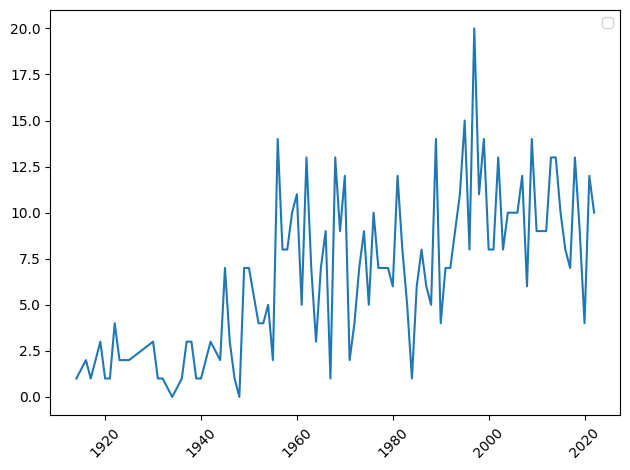

In [74]:
plot_serie(sr_brazil)  

## Fazendo os testes na série - ACF e PACF, Sazonalidade, ADF e KPSS

#### Fazendo metodo de autocorrelação e autocorrelação parcial

In [75]:
def plot_acf_pacf(serie):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    plot_acf(serie, ax=axes[0])
    plot_pacf(serie, ax=axes[1])
    plt.show()

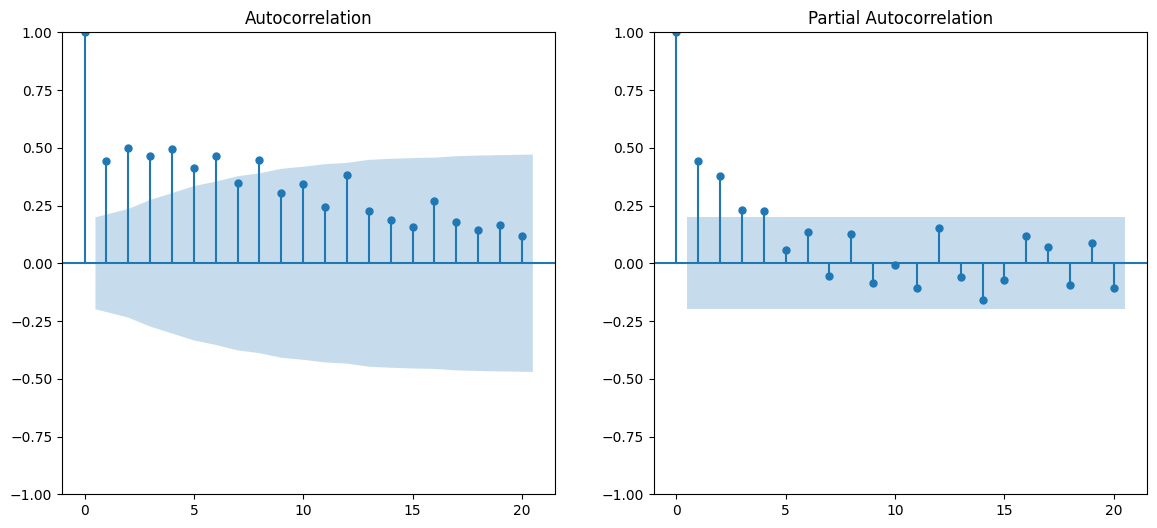

In [76]:
plot_acf_pacf(sr_brazil)

#### Fazendo teste de força sazonal para verificar a sazonalidade da série

In [77]:
valores_m = range(2, 31)

forcas = []

for m in valores_m:
    try:
        stl = STL(sr_brazil, period=m, robust=True).fit()

        forca = 1 - (
            np.var(stl.resid) /
            np.var(stl.seasonal + stl.resid)
        )

        forcas.append(forca)

    except Exception as e:
        print(f'Erro em m = {m}: {e}')

media_forca = np.mean(forcas)
maior_forca = max(forcas)

print('\n-----------------------------------')
print(f'Média da força da sazonalidade: {media_forca:.5f}')
print(f'Maior força da sazonalidade: {maior_forca:.5f} no periodo {valores_m[forcas.index(maior_forca)]}')
print('-----------------------------------')


-----------------------------------
Média da força da sazonalidade: 0.15918
Maior força da sazonalidade: 0.46058 no periodo 29
-----------------------------------


### A SÉRIE NÃO É SAZONAL

#### Fazendo os metodos estatísticos de estacionariedade

In [78]:
def teste_adf(serie, nome):
    resultado = adfuller(serie, autolag='AIC')
    p_valor = resultado[1]
    conclusao = 'ESTACIONÁRIA' if p_valor < 0.05 else 'NÃO ESTACIONÁRIA'
    
    print(f'\nTeste ADF — {nome}')
    print(f'  Estatística ADF: {resultado[0]:.4f}')
    print(f'  p-value:         {p_valor:.6f}')
    print(f'  Lags usados:     {resultado[2]}')
    print(f'  Observações:     {resultado[3]}')
    for key, val in resultado[4].items():
        print(f' Valor crítico {key}: {val:.4f}')
    print(f' Conclusão ADF: {conclusao}')
    return p_valor

def teste_kpss(serie, nome):
    resultado = kpss(serie, regression='c', nlags='auto')
    p_valor = resultado[1]
    conclusao = 'ESTACIONÁRIA' if p_valor >= 0.05 else 'NÃO ESTACIONÁRIA'
    
    print(f'\nTeste KPSS — {nome}')
    print(f'  Estatística KPSS: {resultado[0]:.4f}')
    print(f'  p-value:          {p_valor:.4f}')
    print(f'  Lags usados:      {resultado[2]}')
    for key, val in resultado[3].items():
        print(f'  Valor crítico {key}: {val:.4f}')
    print(f'  Conclusão KPSS: {conclusao}')
    return p_valor

def analise_estacionariedade(serie, nome):
    p_adf = teste_adf(serie, nome)
    p_kpss = teste_kpss(serie, nome)
    
    print(f'\nConclusão combinada para "{nome}"')
    if p_adf < 0.05 and p_kpss >= 0.05:
        print('Ambos os testes concordam: ESTACIONÁRIA')
    elif p_adf >= 0.05 and p_kpss < 0.05:
        print(' Ambos os testes concordam: NÃO ESTACIONÁRIA')
    print('=' * 50)

In [79]:
analise_estacionariedade(sr_brazil, 'Série de vitorias do Brasil')


Teste ADF — Série de vitorias do Brasil
  Estatística ADF: -2.0557
  p-value:         0.262685
  Lags usados:     3
  Observações:     93
 Valor crítico 1%: -3.5027
 Valor crítico 5%: -2.8932
 Valor crítico 10%: -2.5836
 Conclusão ADF: NÃO ESTACIONÁRIA

Teste KPSS — Série de vitorias do Brasil
  Estatística KPSS: 1.3068
  p-value:          0.0100
  Lags usados:      5
  Valor crítico 10%: 0.3470
  Valor crítico 5%: 0.4630
  Valor crítico 2.5%: 0.5740
  Valor crítico 1%: 0.7390
  Conclusão KPSS: NÃO ESTACIONÁRIA

Conclusão combinada para "Série de vitorias do Brasil"
 Ambos os testes concordam: NÃO ESTACIONÁRIA


### A SÉRIE É NÃO ESTACIONÁRIA

## Fazendo modelo SARIMA

In [80]:
# treino teste
h = 10
ytrain = sr_brazil.iloc[:-h]
ytest = sr_brazil.iloc[-h:]


def tentar_sarima(order, seasonal_order, y):
    try:
        model = SARIMAX(
            y,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        res = model.fit(disp=False, maxiter=100)

        return res

    except Exception:
        return None

#### grid search - NAO RODE ESSA CELULA SE VOCE N QUER ZOAR SEU PC

In [81]:
from itertools import product
from statsmodels.tsa.statespace.sarimax import SARIMAX

import warnings
warnings.filterwarnings("ignore")

p_range = range(0, 3)
d_range = range(0, 2)
q_range = range(0, 3)


P_range = range(0, 3)
D_range = range(0, 2)
Q_range = range(0, 3)

m_values = [0, 3, 7]

best_aic = float('inf')

best_bic = None

best_order = None

best_seasonal_order = None

best_model = None

for m in m_values:

    print('\n')
    print('=' * 60)
    print(f'TESTANDO m = {m}')
    print('=' * 60)

    for order in product(
        p_range,
        d_range,
        q_range
    ):

        # CASO NÃO SAZONAL
        if m == 0:

            seasonal_orders = [(0,0,0,0)]


        # CASO SAZONAL
        else:

            seasonal_orders = list(product(
                P_range,
                D_range,
                Q_range
            ))

        for seasonal in seasonal_orders:

            if m == 0:

                seasonal_order = (0,0,0,0)

            else:

                seasonal_order = (
                    seasonal[0],
                    seasonal[1],
                    seasonal[2],
                    m
                )

            try:

                model = SARIMAX(
                    ytrain,
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )

                res = model.fit(disp=False)

                aic = res.aic
                bic = res.bic

                print(
                    f'SARIMA{order}x{seasonal_order} '
                    f'AIC={aic:.2f} '
                    f'BIC={bic:.2f}'
                )
                if aic < best_aic:

                    best_aic = aic

                    best_bic = bic

                    best_order = order

                    best_seasonal_order = seasonal_order

                    best_model = res

            except Exception as e:

                print(
                    f'ERRO EM '
                    f'SARIMA{order}x{seasonal_order}: {e}'
                )

                continue

print(
    f'MELHOR MODELO: '
    f'SARIMA{best_order}x{best_seasonal_order}'
)

print(f'MELHOR AIC: {best_aic:.2f}')

print(f'MELHOR BIC: {best_bic:.2f}')




TESTANDO m = 0
SARIMA(0, 0, 0)x(0, 0, 0, 0) AIC=600.08 BIC=602.54
SARIMA(0, 0, 1)x(0, 0, 0, 0) AIC=554.64 BIC=559.52
SARIMA(0, 0, 2)x(0, 0, 0, 0) AIC=524.33 BIC=531.62
SARIMA(0, 1, 0)x(0, 0, 0, 0) AIC=499.88 BIC=502.33
SARIMA(0, 1, 1)x(0, 0, 0, 0) AIC=445.91 BIC=450.77
SARIMA(0, 1, 2)x(0, 0, 0, 0) AIC=441.59 BIC=448.85
SARIMA(1, 0, 0)x(0, 0, 0, 0) AIC=499.96 BIC=504.87
SARIMA(1, 0, 1)x(0, 0, 0, 0) AIC=452.12 BIC=459.45
SARIMA(1, 0, 2)x(0, 0, 0, 0) AIC=448.43 BIC=458.15
SARIMA(1, 1, 0)x(0, 0, 0, 0) AIC=466.08 BIC=470.97
SARIMA(1, 1, 1)x(0, 0, 0, 0) AIC=445.75 BIC=453.04
SARIMA(1, 1, 2)x(0, 0, 0, 0) AIC=441.97 BIC=451.65
SARIMA(2, 0, 0)x(0, 0, 0, 0) AIC=466.67 BIC=474.00
SARIMA(2, 0, 1)x(0, 0, 0, 0) AIC=452.20 BIC=461.97
SARIMA(2, 0, 2)x(0, 0, 0, 0) AIC=448.16 BIC=460.31
SARIMA(2, 1, 0)x(0, 0, 0, 0) AIC=455.30 BIC=462.59
SARIMA(2, 1, 1)x(0, 0, 0, 0) AIC=447.75 BIC=457.47
SARIMA(2, 1, 2)x(0, 0, 0, 0) AIC=443.84 BIC=455.93


TESTANDO m = 3
SARIMA(0, 0, 0)x(0, 0, 0, 3) AIC=600.08 BIC=602.

SARIMA(0, 1, 2)x(2, 1, 2, 7)
Os parâmetros significam:

- P = 2 → parte autoregressiva sazonal (SAR)
- D = 1 → diferenciação sazonal
- Q = 2 → média móvel sazonal (SMA)
- m = 7 → período sazonal

Como o modelo sazonal ficou (2, 1, 2, 7), então ele é efetivamente um SARIMA, com sazonalidade.

## Analisando a normalidade dos residuos

### Metodo para diagnosticar os residuos com acf e ljung box

In [82]:
def diagnostico_residuos(modelo, lags=30):

    residuos = modelo.resid

    plt.figure(figsize=(10,5))
    plot_acf(residuos, lags=lags)
    plt.title('ACF dos Resíduos')
    plt.show()

    lb = acorr_ljungbox(
        residuos,
        lags=[lags],
        return_df=True
    )

    print('\n===================================')
    print('Teste de Ljung-Box')
    print('===================================')
    print(lb)

    pvalor = lb['lb_pvalue'].values[0]

    if pvalor > 0.05:
        print('Resíduos parecem ruído branco')
        print(f'p-value = {pvalor:.5f}')
    else:
        print('Resíduos NÃO parecem ruído branco')
        print(f'p-value = {pvalor:.5f}')


### Modelo com os melhores parametros

In [83]:
melhor_modelo = SARIMAX(
            ytrain,
            order=best_order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

melhor_modelo_treinado = melhor_modelo.fit()

<Figure size 1000x500 with 0 Axes>

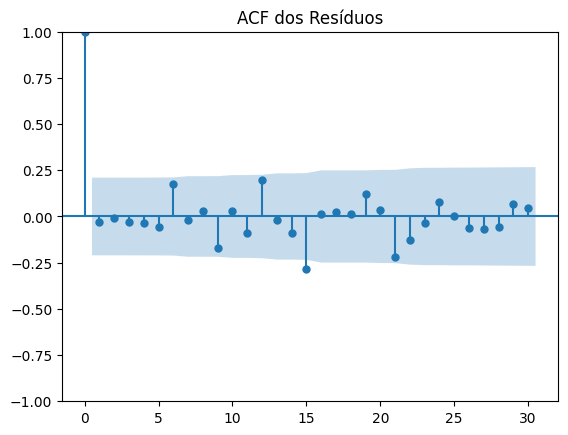


Teste de Ljung-Box
      lb_stat  lb_pvalue
30  33.738166   0.291421
Resíduos parecem ruído branco
p-value = 0.29142


In [84]:
diagnostico_residuos(melhor_modelo_treinado)

### Calculando as métricas de avaliação da serie temporal com roling forecast

In [85]:
def rolling_forecast_modelo(
    modelo_fitado,
    ytrain,
    ytest
):
    order = modelo_fitado.model.order
    seasonal_order = modelo_fitado.model.seasonal_order

    print(f'\nUsando SARIMA{order} x {seasonal_order}')

    history = list(ytrain)

    previsoes = []

    for t in range(len(ytest)):

        model = SARIMAX(
            history,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        res = model.fit(disp=False)

        yhat = res.forecast()[0]

        previsoes.append(yhat)

        history.append(ytest.iloc[t])

    ypred = pd.Series(
        previsoes,
        index=ytest.index
    )

    mae = mean_absolute_error(ytest, ypred)

    mse = mean_squared_error(ytest, ypred)

    rmse = np.sqrt(mse)

    mape = mean_absolute_percentage_error(ytest, ypred) * 100

    r2 = r2_score(ytest, ypred)

    print('\n===================================')
    print('MÉTRICAS ROLLING FORECAST')
    print('===================================')

    print(f'MAE  : {mae:.5f}')
    print(f'MSE  : {mse:.5f}')
    print(f'RMSE : {rmse:.5f}')
    print(f'MAPE : {mape:.2f}%')
    print(f'R²   : {r2:.5f}')

    print('===================================')
    plt.figure(figsize=(14,6))

    plt.plot(ytest.index, ytest, label='Real')

    plt.plot(ytest.index, ypred, label='Previsão')

    plt.title(f'Rolling Forecast SARIMA{order}')

    plt.legend()

    plt.grid(True)

    plt.show()

    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE': mape,
        'R2': r2,
        'predicoes': ypred
    }


Usando SARIMA(0, 1, 2) x (2, 1, 2, 7)

MÉTRICAS ROLLING FORECAST
MAE  : 3.33791
MSE  : 15.69079
RMSE : 3.96116
MAPE : 44.20%
R²   : -0.93953


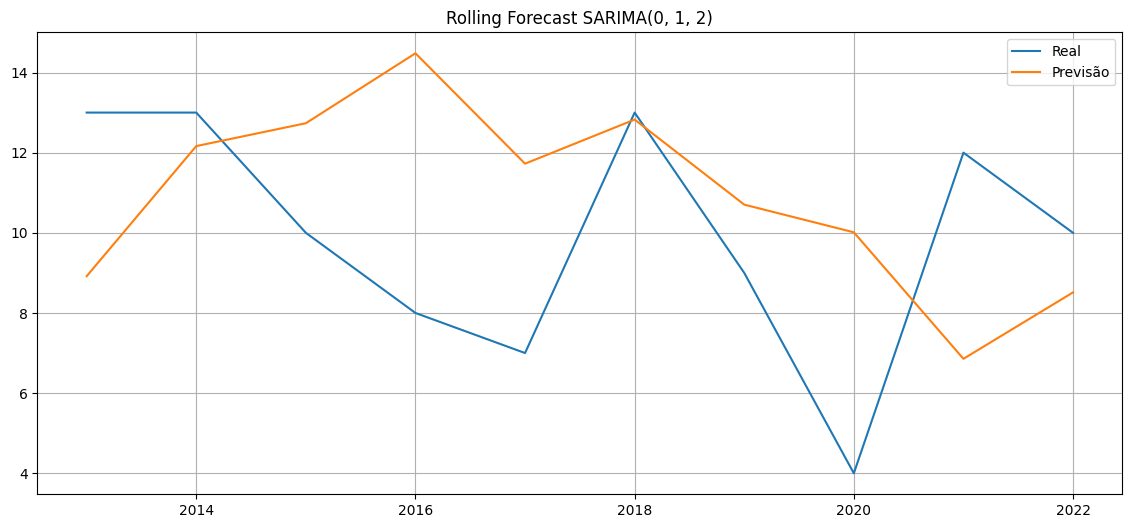

{'MAE': 3.337906531763596,
 'MSE': 15.690785212842291,
 'RMSE': 3.961159579320466,
 'MAPE': 44.19951041889987,
 'R2': -0.9395284564699993,
 'predicoes': year
 2013     8.917524
 2014    12.163618
 2015    12.734300
 2016    14.479758
 2017    11.725063
 2018    12.825516
 2019    10.703240
 2020    10.012600
 2021     6.856301
 2022     8.512938
 dtype: float64}

In [86]:
rolling_forecast_modelo(melhor_modelo_treinado, ytrain, ytest)

In [87]:
def encontrar_melhor_basemodel(
    ytrain,
    ytest
):

    resultados_lista = []

    tamanho_train = len(ytrain)

    # ==========================================
    # função auxiliar
    # ==========================================
    def avaliar(y_real, y_pred):

        mae = mean_absolute_error(y_real, y_pred)

        mse = mean_squared_error(y_real, y_pred)

        rmse = np.sqrt(mse)

        mask = y_real != 0

        if mask.sum() > 0:
            mape = mean_absolute_percentage_error(
                y_real[mask],
                y_pred[mask]
            )
        else:
            mape = np.nan

        return mae, mse, rmse, mape

    # ==========================================
    # 1. MÉDIA HISTÓRICA
    # ==========================================
    pred = pd.Series(
        ytrain.mean(),
        index=ytest.index
    )

    mae, mse, rmse, mape = avaliar(ytest, pred)

    resultados_lista.append({
        'Modelo': 'Média Histórica',
        'Parâmetro': 'Global',
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE': mape
    })

    # ==========================================
    # 2. SMA
    # ==========================================
    for janela in range(1, tamanho_train):

        historico = list(ytrain)

        previsoes = []

        for i in range(len(ytest)):

            valor = np.mean(
                historico[-janela:]
            )

            previsoes.append(valor)

            historico.append(ytest.iloc[i])

        pred = pd.Series(
            previsoes,
            index=ytest.index
        )

        mae, mse, rmse, mape = avaliar(ytest, pred)

        resultados_lista.append({
            'Modelo': 'SMA',
            'Parâmetro': f'Janela={janela}',
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'MAPE': mape
        })

    # ==========================================
    # 3. EMA
    # ==========================================
    alphas = np.round(
        np.arange(0.1, 1.0, 0.1),
        2
    )

    for alpha in alphas:

        historico = list(ytrain)

        previsoes = []

        for i in range(len(ytest)):

            serie_temp = pd.Series(historico)

            valor = serie_temp.ewm(
                alpha=alpha,
                adjust=False
            ).mean().iloc[-1]

            previsoes.append(valor)

            historico.append(ytest.iloc[i])

        pred = pd.Series(
            previsoes,
            index=ytest.index
        )

        mae, mse, rmse, mape = avaliar(ytest, pred)

        resultados_lista.append({
            'Modelo': 'EMA',
            'Parâmetro': f'Alpha={alpha}',
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'MAPE': mape
        })

    # ==========================================
    # 4. SEASONAL NAIVE
    # ==========================================
    for s in range(1, min(30, tamanho_train)):

        historico = list(ytrain)

        previsoes = []

        for i in range(len(ytest)):

            if len(historico) >= s:
                valor = historico[-s]
            else:
                valor = historico[-1]

            previsoes.append(valor)

            historico.append(ytest.iloc[i])

        pred = pd.Series(
            previsoes,
            index=ytest.index
        )

        mae, mse, rmse, mape = avaliar(ytest, pred)

        resultados_lista.append({
            'Modelo': 'Seasonal Naive',
            'Parâmetro': f's={s}',
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'MAPE': mape
        })

    # ==========================================
    # ranking
    # ==========================================
    df = pd.DataFrame(resultados_lista)

    df = df.sort_values(
        by='RMSE'
    ).reset_index(drop=True)

    melhor = df.iloc[0]

    print('\n===================================')
    print('MELHOR BASEMODEL')
    print('===================================')

    print(f"Modelo: {melhor['Modelo']}")

    print(f"Parâmetro: {melhor['Parâmetro']}")

    print(f"RMSE: {melhor['RMSE']:.5f}")

    print('===================================')

    return df

### Comparação do melhor base model com o melhor SARIMA

In [88]:
def comparar_sarima_vs_basemodel(
    modelo_sarima,
    ytrain,
    ytest
):

    resultado_sarima = rolling_forecast_modelo(
        modelo_sarima,
        ytrain,
        ytest
    )

    rmse_sarima = resultado_sarima['RMSE']

    ranking_basemodel = encontrar_melhor_basemodel(
        ytrain,
        ytest
    )

    melhor_basemodel = ranking_basemodel.iloc[0]

    rmse_base = melhor_basemodel['RMSE']


  
    print('=' * 60)
    print('COMPARAÇÃO FINAL')
    print('=' * 60)

    print(f'SARIMA RMSE:     {rmse_sarima:.5f}')
    print(f'BASEMODEL RMSE:  {rmse_base:.5f}')



    
    if rmse_sarima < rmse_base:

        print(' SARIMA É MELHOR')
        print('\nModelo vencedor:')

        print(
            f'ARIMA{modelo_sarima.model.order} '
            f'x {modelo_sarima.model.seasonal_order}'
        )

        vencedor = {
            'tipo': 'SARIMA',
            'rmse': rmse_sarima,
            'modelo': f'ARIMA{modelo_sarima.model.order}'
        }

    else:

        print('BASEMODEL É MELHOR')

        print('\nMelhor basemodel:')

        print(f"Modelo:    {melhor_basemodel['Modelo']}")
        print(f"Parâmetro: {melhor_basemodel['Parâmetro']}")

        vencedor = {
            'tipo': 'BASEMODEL',
            'rmse': rmse_base,
            'modelo': melhor_basemodel['Modelo'],
            'parametro': melhor_basemodel['Parâmetro']
        }

    print('=' * 60)

    resumo = pd.DataFrame([
        {
            'Modelo': 'SARIMA',
            'RMSE': rmse_sarima
        },
        {
            'Modelo': melhor_basemodel['Modelo'],
            'RMSE': rmse_base
        }
    ]).sort_values(by='RMSE')

    return {
        'vencedor': vencedor,
        'resumo': resumo,
        'ranking_basemodel': ranking_basemodel,
        'resultado_sarima': resultado_sarima
    }


Usando SARIMA(0, 1, 2) x (2, 1, 2, 7)

MÉTRICAS ROLLING FORECAST
MAE  : 3.33791
MSE  : 15.69079
RMSE : 3.96116
MAPE : 44.20%
R²   : -0.93953


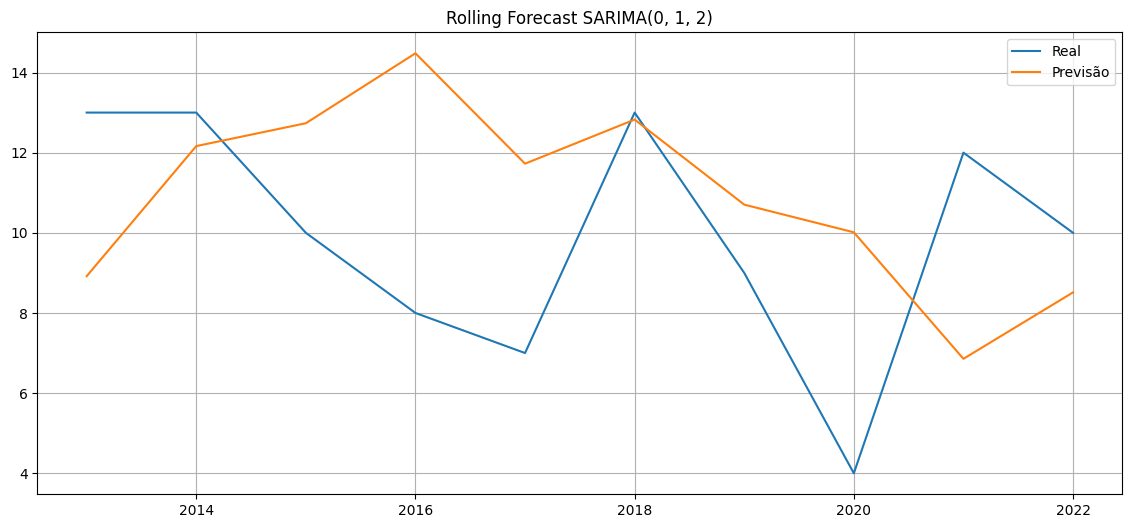


MELHOR BASEMODEL
Modelo: Seasonal Naive
Parâmetro: s=12
RMSE: 2.62679
COMPARAÇÃO FINAL
SARIMA RMSE:     3.96116
BASEMODEL RMSE:  2.62679
BASEMODEL É MELHOR

Melhor basemodel:
Modelo:    Seasonal Naive
Parâmetro: s=12
           Modelo      RMSE
1  Seasonal Naive  2.626785
0          SARIMA  3.961160


In [89]:
resultado = comparar_sarima_vs_basemodel(
    melhor_modelo_treinado,
    ytrain,
    ytest
)

print(resultado['resumo'])